# ch312 — Optimisers: Adam, RMSProp, Momentum

## 1. The problem with vanilla SGD

SGD uses the same learning rate for all parameters. But gradients have very different
scales across parameters: weights in a sparse input layer update rarely (small gradient),
weights in a dense hidden layer update every batch (large gradient).

**Adaptive optimisers** maintain per-parameter learning rates that automatically scale
with the history of each parameter's gradients.

*(SGD and momentum: ch307.)*

---

## 2. AdaGrad

$$G_t = G_{t-1} + g_t^2, \quad \theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{G_t + \varepsilon}} g_t$$

$G_t$ accumulates squared gradients. Parameters with large historical gradients get small
effective LR; sparse parameters get large effective LR. Problem: $G_t$ only grows → LR
monotonically decreases → learning stops.

---

## 3. RMSProp

Replace the accumulation with an exponential moving average:

$$v_t = \rho v_{t-1} + (1-\rho) g_t^2, \quad \theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{v_t + \varepsilon}} g_t$$

$\rho \approx 0.9$. The decay prevents $v_t$ from growing without bound.

---

## 4. Adam (Adaptive Moment Estimation)

Adam *(Kingma & Ba, 2014)* combines RMSProp (second moment) with momentum (first moment):

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \quad \text{(first moment — mean)}$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2 \quad \text{(second moment — uncentred variance)}$$

**Bias correction** (important at $t=1$ when $m_t$ and $v_t$ are near zero):
$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t}$$

$$\theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{\hat{v}_t} + \varepsilon} \hat{m}_t$$

Defaults: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\varepsilon = 10^{-8}$, $\eta = 10^{-3}$.

**Adam is the standard default** for most deep learning tasks.

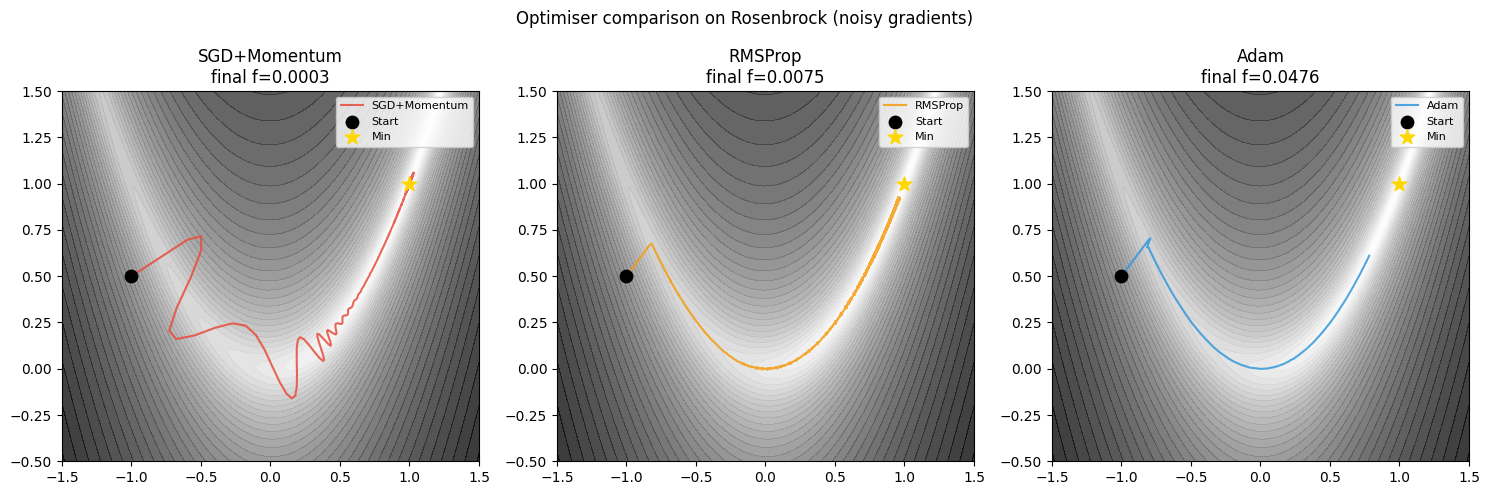

In [1]:
import numpy as np
import matplotlib.pyplot as plt


class SGDMomentum:
    def __init__(self, params, lr=0.01, momentum=0.9):
        self.params = params; self.lr = lr; self.mu = momentum
        self.v = {k: np.zeros_like(v) for k, v in params.items()}
    def step(self, grads):
        for k in self.params:
            self.v[k] = self.mu*self.v[k] - self.lr*grads[k]
            self.params[k] += self.v[k]

class RMSProp:
    def __init__(self, params, lr=0.01, rho=0.9, eps=1e-8):
        self.params = params; self.lr = lr; self.rho = rho; self.eps = eps
        self.v = {k: np.zeros_like(v) for k, v in params.items()}
    def step(self, grads):
        for k in self.params:
            self.v[k] = self.rho*self.v[k] + (1-self.rho)*grads[k]**2
            self.params[k] -= self.lr / (np.sqrt(self.v[k]) + self.eps) * grads[k]

class Adam:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = params; self.lr = lr
        self.b1 = beta1; self.b2 = beta2; self.eps = eps; self.t = 0
        self.m = {k: np.zeros_like(v) for k, v in params.items()}
        self.v = {k: np.zeros_like(v) for k, v in params.items()}
    def step(self, grads):
        self.t += 1
        for k in self.params:
            self.m[k] = self.b1*self.m[k] + (1-self.b1)*grads[k]
            self.v[k] = self.b2*self.v[k] + (1-self.b2)*grads[k]**2
            m_hat = self.m[k] / (1 - self.b1**self.t)
            v_hat = self.v[k] / (1 - self.b2**self.t)
            self.params[k] -= self.lr / (np.sqrt(v_hat) + self.eps) * m_hat


def rosenbrock(p): return (1-p[0])**2 + 100*(p[1]-p[0]**2)**2
def rosenbrock_grad(p):
    return np.array([-2*(1-p[0]) - 400*p[0]*(p[1]-p[0]**2),
                     200*(p[1]-p[0]**2)])


def run_optimiser(opt_cls, opt_kwargs, n_steps=2000, seed=0):
    rng = np.random.default_rng(seed)
    params = {'w': np.array([-1.0, 0.5])}
    opt = opt_cls(params, **opt_kwargs)
    hist = [params['w'].copy()]
    for _ in range(n_steps):
        g = rosenbrock_grad(params['w']) + rng.normal(0, 0.3, 2)
        opt.step({'w': g})
        hist.append(params['w'].copy())
    return np.array(hist)

configs = [
    (SGDMomentum, {'lr': 0.001, 'momentum': 0.9}, 'SGD+Momentum', '#e74c3c'),
    (RMSProp, {'lr': 0.005, 'rho': 0.9}, 'RMSProp', '#f39c12'),
    (Adam, {'lr': 0.01}, 'Adam', '#3498db'),
]

xs = np.linspace(-1.5, 1.5, 400); ys = np.linspace(-0.5, 1.5, 400)
X, Y = np.meshgrid(xs, ys)
Z = np.log1p((1-X)**2 + 100*(Y-X**2)**2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (opt_cls, kwargs, name, color) in zip(axes, configs):
    hist = run_optimiser(opt_cls, kwargs)
    ax.contourf(X, Y, Z, levels=40, cmap='gray_r', alpha=0.8)
    ax.plot(hist[:,0], hist[:,1], color=color, lw=1.5, alpha=0.85, label=name)
    ax.scatter(-1, 0.5, color='black', s=80, zorder=5, label='Start')
    ax.scatter(1, 1, color='gold', s=120, marker='*', zorder=5, label='Min')
    final = rosenbrock(hist[-1])
    ax.set_title(f'{name}\nfinal f={final:.4f}')
    ax.set_xlim(-1.5,1.5); ax.set_ylim(-0.5,1.5)
    ax.legend(fontsize=8)

plt.suptitle('Optimiser comparison on Rosenbrock (noisy gradients)', fontsize=12)
plt.tight_layout()
plt.savefig('ch312_optimisers.png', dpi=120)
plt.show()

## 5. AdamW: fixing Adam's L2 regularisation

Standard Adam with L2 penalty mixes gradient adaption and weight decay, causing
inconsistent effective regularisation. **AdamW** (Loshchilov & Hutter, 2019) decouples them:

$$\theta_t = \theta_{t-1} - \frac{\eta}{\sqrt{\hat{v}_t}+\varepsilon}\hat{m}_t - \eta\lambda\theta_{t-1}$$

Weight decay applied directly to parameters, not via the gradient.
AdamW is the default optimiser for Transformers and language models.

---

## 6. Practical guidelines

| Task | Recommended optimiser |
|---|---|
| Quick prototyping | Adam (lr=1e-3) |
| CNNs for vision | SGD+Momentum (lr=0.01–0.1, μ=0.9) |
| Transformers/LLMs | AdamW (lr=1e-4 to 3e-4, weight_decay=0.01) |
| RNNs | Adam or RMSProp with gradient clipping |
| Reinforcement Learning | Adam or RMSProp |

---

## 7. Summary

- Adaptive optimisers scale LR per-parameter based on gradient history.
- RMSProp: EMA of squared gradients; Adam: RMSProp + momentum + bias correction.
- Adam defaults work surprisingly well across tasks; AdamW fixes L2 coupling.
- SGD+Momentum often beats Adam on final test accuracy for CNNs, given more tuning.

---

## 8. Forward and backward references

**Used here:** gradient descent *(ch212)*, momentum *(ch307)*, expectation *(ch249)*,
L2 regularisation *(ch311)*.

**This will reappear in ch322 — Transformers**, where AdamW with linear warmup and
cosine decay is the universal training recipe for language models.